# Daily Variation

We will not use the last 3 values because we don't have the real values for all horizons (H=1).
data:  {'precision_values': [(6065.25, 6065.7236, 6069.75), (6069.75, 6070.0195, 6070.0), (6070.0, 6070.4067, 6074.75), (6074.75, 6078.673, 6079.0), (6079.0, 6077.5654, 6080.5), (6080.5, 6081.3613, 6079.75), (6079.75, 6080.2344, 6082.25), (6082.25, 6083.001, 6082.0), (6082.0, 6082.08, 6075.25), (6075.25, 6069.749, 6048.0), (6048.0, 6047.4893, 6051.25), (6051.25, 6044.795, 6042.25), (6042.25, 6046.1533, 6054.5), (6054.5, 6061.161, 6056.5), (6056.5, 6056.5293, 6055.75), (6055.75, 6053.414, 6051.25), (6051.25, 6054.1504, 6051.36), (6051.36, 6050.962, 6051.47), (6051.47, 6051.6763, 6051.58), (6051.58, 6051.58, 6051.69), (6051.69, 6051.7256, 6051.8), (6051.8, 6052.0586, 6051.91), (6051.91, 6052.3647, 6052.02), (6052.02, 6052.318, 6052.13)], 'opening_price': 6066.0, 'closing_price': 6052.02}
date:  2024-12-13
data:  {'precision_values': [(6052.13, 6052.284, 6052.24), (6052.24, 6052.175, 6052.35), 

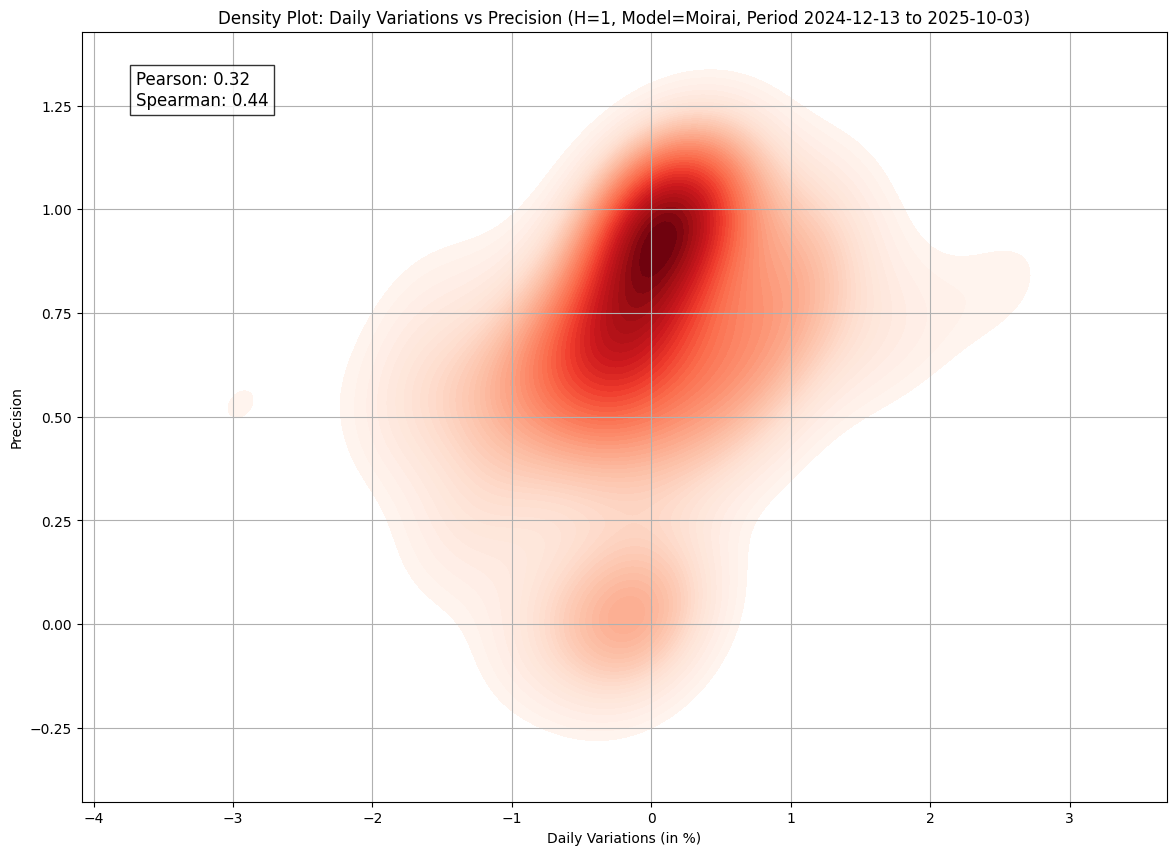

In [9]:
import pandas as pd
import ast
from math import prod
from datetime import datetime
import numpy as np

# We fix the horizon to 1 because otherwise it's too complicated to handle multiple horizons at the same time

# 1. Load the CSV (same file for all horizons)
df_moirai = pd.read_csv("analysis/future_data/test/es_future_final_moirai_2024_2025.csv")

# 2. Drop the first context_length rows because they have missing values for Result (NaN)
#    Keep the last 3 rows as a reference for the last 3 predicted values
df_moirai = df_moirai.drop(df_moirai.index[:383])

# 3. Shared configuration for all horizons
prediction_length = 3
horizon_index = 0
horizon = horizon_index + 1
last_index = df_moirai.index[-1]
last_index_for_es = last_index - prediction_length

# 4. Get the relevant values for a day
current_day = None
close_price = 0
opening_price = 0

# 5. Create a dictionary to store the values for each day
#    The keys will be the dates and the values will be dictionaries containing the precision values
#    and the opening and closing prices
#    The dictionary will look like this:
#    {
#        "2023-03-28": {
#            "precision_values": [(current_price, predicted_price, future_price)],
#            "opening_price": opening_price,
#            "closing_price": closing_price,
#            "daily_variation": daily_variation,
#            "precision": precision
#        },
#        ...
#    }
day_dict = {}

# 6. Iterate through DataFrame rows
for index_in_df, row in df_moirai.iterrows():
    current_price = float(row["Close"])
    if index_in_df > last_index_for_es:
        print(f"We will not use the last 3 values because we don't have the real values for all horizons (H={horizon}).")
        break

    predictions_list = ast.literal_eval(row["Result"])
    future_prices = df_moirai.loc[index_in_df:].iloc[1:prediction_length+1]["Close"].tolist()
    
    predicted_price = predictions_list[horizon_index]
    future_price = future_prices[horizon_index]

    date = datetime.fromisoformat(row["Datetime"]).date()

    # if date == datetime.fromisoformat("2023-03-28").date():
    if date == datetime.fromisoformat("2024-12-12").date() or date == datetime.fromisoformat("2025-03-10").date():
        # This date as only one value so we can't do closing and opening price
        continue

    if date == current_day:
        day_dict[f"{date}"]["precision_values"].append((current_price, predicted_price, future_price))
    else:
        current_day = date
        day_dict[f"{date}"] = {}
        day_dict[f"{date}"]["precision_values"] = [(current_price, predicted_price, future_price)]

    # if column Hour doesn't exist in the df_moirai, we create it
    if "Hour" not in df_moirai.columns:
        df_moirai["Hour"] = df_moirai["Datetime"].apply(lambda x: datetime.fromisoformat(x).hour)

    hour = row["Hour"]
    if hour == 23:
        close_price = float(row["Close"])
        day_dict[f"{date}"]["closing_price"] = close_price
    if hour == 0:
        opening_price = float(row["Open"])
        day_dict[f"{date}"]["opening_price"] = opening_price


# 7. Post-process: fill the opening and closing prices if the first hour is not 0 and the last hour is not 23
# We only want day with more than one value
for date, data in day_dict.items():
    precision_values = data.get("precision_values", [])
    if len(precision_values) > 1:
        if data.get("opening_price") is None:
            # Extract the first element from the precision values
            prices = [current_price for current_price, predicted_price, future_price in precision_values]
            day_dict[date]["opening_price"] = prices[0]
        if data.get("closing_price") is None:
            # Extract the last element from the precision values
            prices = [current_price for current_price, predicted_price, future_price in precision_values]
            day_dict[date]["closing_price"] = prices[-1]

# 8. Compute the daily variation and precision for each day
for date, data in day_dict.items():

    print("data: ", data)
    print("date: ", date)
    
    # Daily variation 
    opening_price = data["opening_price"]
    closing_price = data["closing_price"]
    daily_variation = ((closing_price - opening_price) / opening_price) *  100
    day_dict[date]["daily_variation"] = daily_variation
    
    # Precision
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    precision_values = data["precision_values"]
    for (current_price, predicted_price, future_price) in precision_values:
        sign_real_difference = np.sign(future_price - current_price)
        sign_prediction_difference = np.sign(predicted_price - current_price)
    
        if sign_prediction_difference == 1 and sign_real_difference == 1:
            TP += 1
        elif sign_prediction_difference == -1 and sign_real_difference == -1:
            TN += 1
        elif sign_prediction_difference == 1 and sign_real_difference == -1:
            FP += 1
        elif sign_prediction_difference == -1 and sign_real_difference == 1:
            FN += 1
    # Calculate precision
    if TP + FP == 0:
        precision = 0
    else:
        precision = TP / (TP + FP)
    # store this in the dictionary
    day_dict[date]["precision"] = precision

# 9. Plot the daily variation (x-axis) and precision (y-axis) using KDE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image

daily_variations = []
precisions = []
for date, data in day_dict.items():
    daily_variations.append(data["daily_variation"])
    precisions.append(data["precision"])

print("max precision", max(precisions))


# Créer un DataFrame à partir des listes
df = pd.DataFrame({
    'daily_variation': daily_variations,
    'precision': precisions
})

# Calculer les corrélations
pearson_corr = df[['daily_variation', 'precision']].corr(method='pearson')
spearman_corr = df[['daily_variation', 'precision']].corr(method='spearman')
print("Pearson Correlation:\n", pearson_corr)
print("Spearman Correlation:\n", spearman_corr)

# Créer un graphique KDE
plt.figure(figsize=(14, 10))
sns.kdeplot(data=df, x='daily_variation', y='precision', fill=True, cmap="Reds", levels=50)

# Ajouter les coefficients de corrélation comme texte
plt.text(0.05, 0.95, 
         f"Pearson: {pearson_corr.iloc[0, 1]:.2f}\nSpearman: {spearman_corr.iloc[0, 1]:.2f}", 
         fontsize=12, 
         transform=plt.gca().transAxes, 
         verticalalignment='top', 
         bbox=dict(facecolor='white', alpha=0.8))

# Titre et labels
plt.title("Density Plot: Daily Variations vs Precision (H=1, Model=Moirai, Period 2024-12-13 to 2025-10-03)")
plt.xlabel('Daily Variations (in %)')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

# Daily/Weekly variation

We will not use the last 3 values because we don't have the real values for all horizons (H=1).


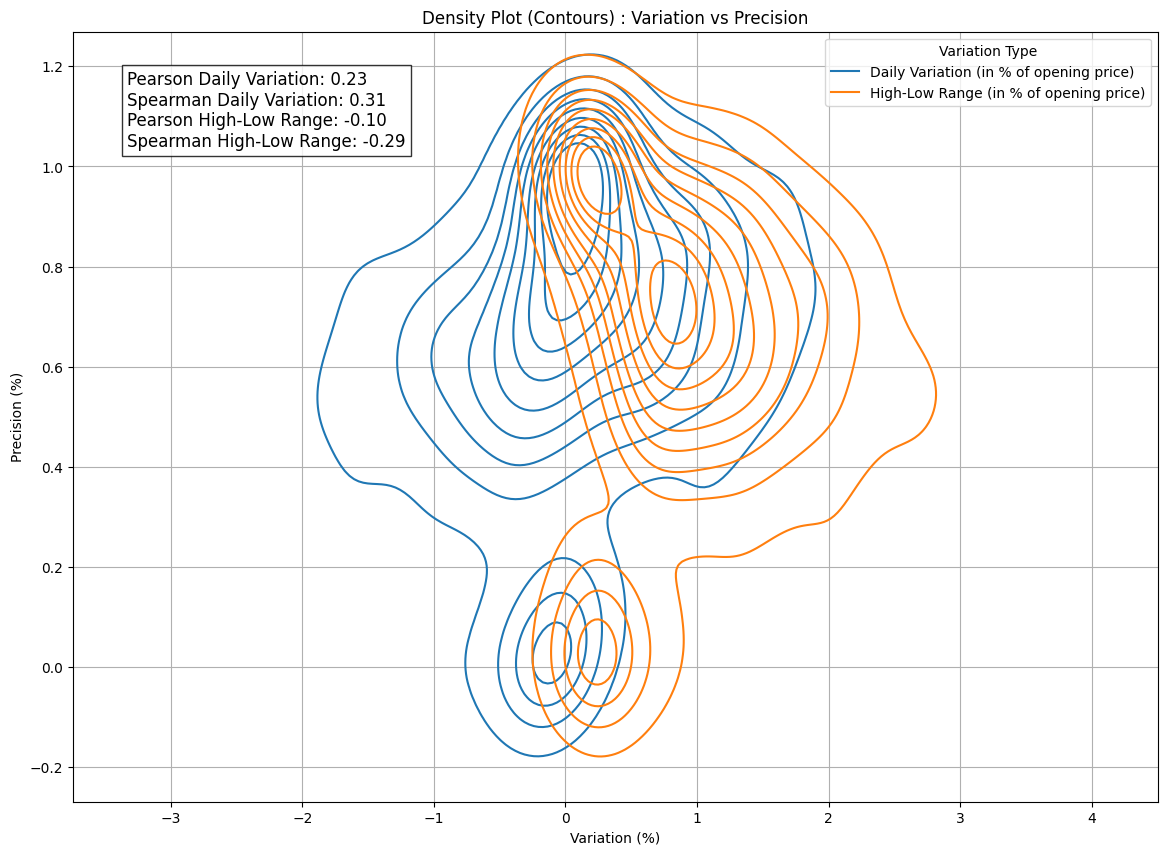

In [1]:
import pandas as pd
import ast
from math import prod
from datetime import datetime
import numpy as np

# We fix the horizon to 1 because otherwise it's too complicated to handle multiple horizons at the same time

# 1. Load the CSV (same file for all horizons)
df_moirai = pd.read_csv("analysis/future_data/es_future_final_moirai_2023_2025.csv")

# 2. Drop the first context_length rows because they have missing values for Result (NaN)
#    Keep the last 3 rows as a reference for the last 3 predicted values
df_moirai = df_moirai.drop(df_moirai.index[:383])

# 3. Shared configuration for all horizons
prediction_length = 3
horizon_index = 0
horizon = horizon_index + 1
last_index = df_moirai.index[-1]
last_index_for_pred = last_index - prediction_length

# 4. Get the relevant values for a week
current_week_year_key = None
current_day = None

# 5. Create a dictionary to store the values for each week
week_dict = {}

# 6. Iterate through DataFrame rows
for index_in_df, row in df_moirai.iterrows():
    current_price = float(row["Close"])
    if index_in_df > last_index_for_pred:
        print(f"We will not use the last 3 values because we don't have the real values for all horizons (H={horizon}).")
        break

    predictions_list = ast.literal_eval(row["Result"])
    future_prices = df_moirai.loc[index_in_df:].iloc[1:prediction_length+1]["Close"].tolist()
    
    predicted_price = predictions_list[horizon_index]
    future_price = future_prices[horizon_index]

    # Get the date and determine day, week and year
    date = datetime.fromisoformat(row["Datetime"]).date()
    year = date.year
    week = date.isocalendar()[1]  # Get ISO week number
    week_year_key = f"{year}-W{week:02d}"  # Format: "YYYY-WNN"
    day = date.day

    if week_year_key != current_week_year_key:
        current_week_year_key = week_year_key
        week_dict[week_year_key] = {}

    if day != current_day:
        current_day = day
        week_dict[week_year_key][day] = {}
        week_dict[week_year_key][day]["precision_values"] = []
        week_dict[week_year_key][day]["opening_prices"] = []
        week_dict[week_year_key][day]["closing_prices"] = []
        week_dict[week_year_key][day]["daily_variations"] = 0
        week_dict[week_year_key][day]["max_high"] = float("-inf")
        week_dict[week_year_key][day]["min_low"] = float("inf")

    # Add the opening/closing prices in order to extract later the first and last values in the list for opening and closing prices
    week_dict[week_year_key][day]["closing_prices"].append(float(row["Close"]))
    week_dict[week_year_key][day]["opening_prices"].append(float(row["Open"]))
    
    # Add the max high and min low for the day
    week_dict[week_year_key][day]["max_high"] = max(week_dict[week_year_key][day]["max_high"], float(row["High"]))
    week_dict[week_year_key][day]["min_low"] = min(week_dict[week_year_key][day]["min_low"], float(row["Low"]))

    # Add the values to compute the precision
    week_dict[week_year_key][day]["precision_values"].append((current_price, predicted_price, future_price))


# 7. Calculate daily/weekly variations and precision for each week
for week_year_key, data in week_dict.items():
    for day, day_data in data.items():
        # Add the opening and closing prices of the day
        week_dict[week_year_key][day]["opening_price"] = day_data["opening_prices"][0]
        week_dict[week_year_key][day]["closing_price"] = day_data["closing_prices"][-1]
        # Compute the daily variation using these new keys
        daily_variation = ((week_dict[week_year_key][day]["closing_price"] - week_dict[week_year_key][day]["opening_price"]) / week_dict[week_year_key][day]["opening_price"]) * 100
        week_dict[week_year_key][day]["daily_variation"] = daily_variation
        # Compute the high-low range of the day in percentage of the opening price
        high_low_range = ((week_dict[week_year_key][day]["max_high"] - week_dict[week_year_key][day]["min_low"]) / week_dict[week_year_key][day]["opening_price"]) * 100
        week_dict[week_year_key][day]["high_low_range"] = high_low_range
        # Compute precision for the day
        TP, TN, FP, FN = 0, 0, 0, 0
        precision_values = day_data["precision_values"]
        for (current_price, predicted_price, future_price) in precision_values:
            sign_real_difference = np.sign(future_price - current_price)
            sign_prediction_difference = np.sign(predicted_price - current_price)
        
            if sign_prediction_difference == 1 and sign_real_difference == 1:
                TP += 1
            elif sign_prediction_difference == -1 and sign_real_difference == -1:
                TN += 1
            elif sign_prediction_difference == 1 and sign_real_difference == -1:
                FP += 1
            elif sign_prediction_difference == -1 and sign_real_difference == 1:
                FN += 1
        # Calculate precision
        if TP + FP == 0:
            # set to nan
            precision = np.nan
        else:
            precision = TP / (TP + FP)
        # store this in the dictionary
        week_dict[week_year_key][day]["precision"] = precision
        # Store the number of data points for reference
        week_dict[week_year_key][day]["data_points"] = len(precision_values)

    # -- Weekly variation --
    # Calculate weekly variation as the average of daily variations
    # obtain the keys of the day for a week and extract the first and last ones
    # week_days = list(week_dict[week_year_key].keys())
    # first_day, last_day = week_days[0], week_days[-1]
    # weekly_variation = ((week_dict[week_year_key][last_day]["closing_price"] - week_dict[week_year_key][first_day]["opening_price"]) / week_dict[week_year_key][first_day]["opening_price"]) * 100
    # week_dict[week_year_key]["weekly_variation"] = weekly_variation

# 9. Plot
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image

daily_variations_list = []
high_low_range_list = []
for week_year_key, data in week_dict.items():
    for day, day_data in data.items():
        if not np.isnan(day_data["precision"]): #filter out NaN values so the day with only one value is not taken into account
            daily_variation = day_data["daily_variation"]
            high_low_range = day_data["high_low_range"]
            precision = day_data["precision"]
            daily_variations_list.append((precision, daily_variation))
            high_low_range_list.append((precision, high_low_range))


# Create a dataframe with the daily variations and high low range
df = pd.DataFrame({
    'precision': [precision for precision, daily_variation in daily_variations_list],
    'daily_variation': [daily_variation for precision, daily_variation in daily_variations_list],
    'high_low_range': [high_low_range for precision, high_low_range in high_low_range_list],
})


df_melt = df.melt(
    id_vars='precision', 
    value_vars=['daily_variation', 'high_low_range'], 
    var_name='Variation Type', 
    value_name='variation'
)

# Change labels for visibility:
df_melt['Variation Type'] = df_melt['Variation Type'].replace({
    'daily_variation': 'Daily Variation (in % of opening price)',
    'high_low_range': 'High-Low Range (in % of opening price)'
})


# Correlation coefficients
pearson_corr_daily_var = df[['daily_variation', 'precision']].corr(method='pearson')
spearman_corr_daily_var = df[['daily_variation', 'precision']].corr(method='spearman')

pearson_corr_high_low_range = df[['high_low_range', 'precision']].corr(method='pearson')
spearman_corr_high_low_range = df[['high_low_range', 'precision']].corr(method='spearman')

plt.figure(figsize=(14, 10))


# Plot the density contours (unfilled lines)
sns.kdeplot(
    data=df_melt, 
    x='variation', 
    y='precision', 
    hue='Variation Type', 
    fill=False,           
    #levels=10
)

# Limit y-axis (precision) between 0 and 1
# plt.ylim(0, 1)

# Label the axes
plt.xlabel("Variation (%)")
plt.ylabel("Precision (%)")
plt.title("Density Plot (Contours) : Variation vs Precision")

# Add the correlation coefficients to the plot
plt.text(0.05, 0.95,
         f"Pearson Daily Variation: {pearson_corr_daily_var.iloc[0, 1]:.2f}\n"
         f"Spearman Daily Variation: {spearman_corr_daily_var.iloc[0, 1]:.2f}\n"
         f"Pearson High-Low Range: {pearson_corr_high_low_range.iloc[0, 1]:.2f}\n"
         f"Spearman High-Low Range: {spearman_corr_high_low_range.iloc[0, 1]:.2f}",
         fontsize=12,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8))

plt.grid(True)

# Save the heatmap image and then compress it
output_path = "analysis/notebooks/discrepancy_analysis/density_plot_daily_variation_vs_precision.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
Image.open(output_path).save(output_path, format="PNG", optimize=True, compress_level=9)

plt.show()

# Distribution of data

Quartiles of daily_variation : 0.00   -3.077993
0.25   -0.206499
0.50    0.028694
0.75    0.354397
1.00    2.562906
Name: daily_variation, dtype: float64

Quartiles of high_low_range : 0.00    0.036393
0.25    0.357468
0.50    0.784046
0.75    1.255004
1.00    3.869637
Name: high_low_range, dtype: float64

Number of points on the graph : 703


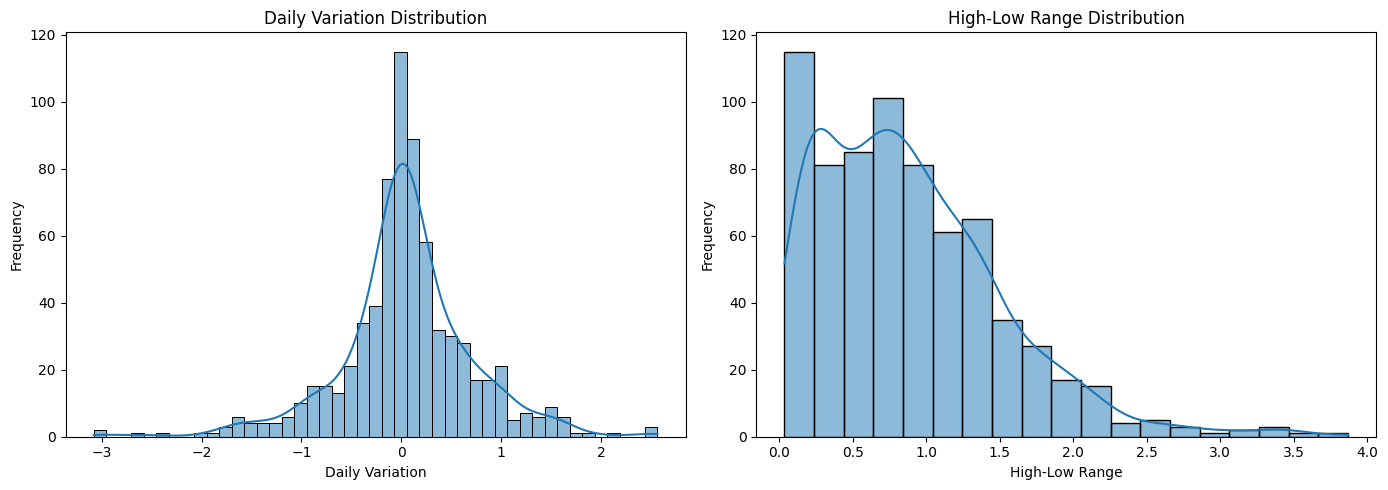

In [ ]:
# Daily variation quartiles
q_daily = df['daily_variation'].quantile([0.0, 0.25, 0.5, 0.75, 1.0])
print("Quartiles of daily_variation :", q_daily)

# High-low range quartiles
q_range = df['high_low_range'].quantile([0.0, 0.25, 0.5, 0.75, 1.0])
print("\nQuartiles of high_low_range :", q_range)


# Print the number of points on the graph
print("\nNumber of points on the graph :", len(df))

import matplotlib.pyplot as plt
import seaborn as sns

# Création des graphiques de distribution
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de daily_variation (axe X)
sns.histplot(df['daily_variation'], kde=True, ax=axs[0])
axs[0].set_title("Daily Variation Distribution")
axs[0].set_xlabel("Daily Variation")
axs[0].set_ylabel("Frequency")

# Distribution de high_low_range (axe Y)
sns.histplot(df['high_low_range'], kde=True, ax=axs[1])
axs[1].set_title("High-Low Range Distribution")
axs[1].set_xlabel("High-Low Range")
axs[1].set_ylabel("Frequency")

plt.tight_layout()

# Save the heatmap image and then compress it
output_path = "analysis/notebooks/discrepancy_analysis/distribution_daily_variation_high_low_range.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
Image.open(output_path).save(output_path, format="PNG", optimize=True, compress_level=9)

plt.show()

# High Low Daily

We will not use the last 3 values because we don't have the real values for all horizons (H=1).
max precision 1.0
Pearson Correlation:
                 high_low_range  precision
high_low_range        1.000000  -0.095121
precision            -0.095121   1.000000
Spearman Correlation:
                 high_low_range  precision
high_low_range         1.00000   -0.29324
precision             -0.29324    1.00000


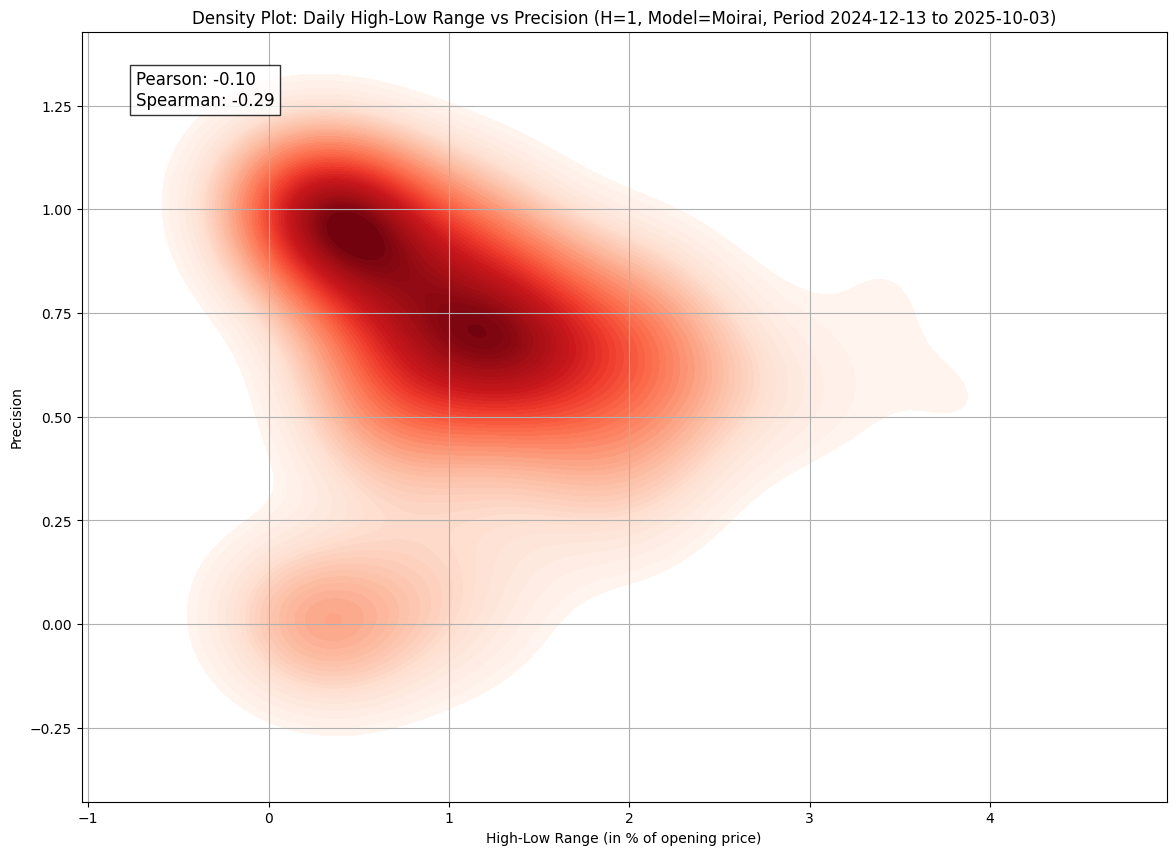

In [ ]:
import pandas as pd
import ast
from math import prod
from datetime import datetime
import numpy as np

# We fix the horizon to 1 because otherwise it's too complicated to handle multiple horizons at the same time

# 1. Load the CSV (same file for all horizons)
df_moirai = pd.read_csv("analysis/future_data/test/es_future_final_moirai_2024_2025.csv")

# 2. Drop the first context_length rows because they have missing values for Result (NaN)
#    Keep the last 3 rows as a reference for the last 3 predicted values
df_moirai = df_moirai.drop(df_moirai.index[:383])

# 3. Shared configuration for all horizons
prediction_length = 3
horizon_index = 0
horizon = horizon_index + 1
last_index = df_moirai.index[-1]
last_index_for_es = last_index - prediction_length

# 4. Get the relevant values for a day
current_day = None
opening_price = 0
max_high = float('-inf')  # Initialize to negative infinity
min_low = float('inf')    # Initialize to positive infinity

# 5. Create a dictionary to store the values for each day
#    The keys will be the dates and the values will be dictionaries containing the precision values
#    and the opening, as well as max high and min low
#    The dictionary will look like this:
#    {
#        "2023-03-28": {
#            "precision_values": [(current_price, predicted_price, future_price)],
#            "opening_price": opening_price,
#            "max_high": max_high,
#            "min_low": min_low,
#            "high_low_range": high_low_range,
#            "precision": precision
#        },
#        ...
#    }
day_dict = {}

# 6. Iterate through DataFrame rows
for index_in_df, row in df_moirai.iterrows():
    current_price = float(row["Close"])
    if index_in_df > last_index_for_es:
        print(f"We will not use the last 3 values because we don't have the real values for all horizons (H={horizon}).")
        break

    predictions_list = ast.literal_eval(row["Result"])
    future_prices = df_moirai.loc[index_in_df:].iloc[1:prediction_length+1]["Close"].tolist()
    
    predicted_price = predictions_list[horizon_index]
    future_price = future_prices[horizon_index]

    date = datetime.fromisoformat(row["Datetime"]).date()
    
    current_high = float(row["High"])
    current_low = float(row["Low"])
    
    # if date == datetime.fromisoformat("2023-03-28").date():
    if date == datetime.fromisoformat("2024-12-12").date() or date == datetime.fromisoformat("2025-03-10").date():
        # This date as only one value so we can't do closing and opening price
        continue

    if date == current_day:
        day_dict[f"{date}"]["precision_values"].append((current_price, predicted_price, future_price))
        # Update max high and min low
        day_dict[f"{date}"]["max_high"] = max(day_dict[f"{date}"]["max_high"], current_high)
        day_dict[f"{date}"]["min_low"] = min(day_dict[f"{date}"]["min_low"], current_low)
    else:
        current_day = date
        day_dict[f"{date}"] = {}
        day_dict[f"{date}"]["precision_values"] = [(current_price, predicted_price, future_price)]
        day_dict[f"{date}"]["max_high"] = current_high
        day_dict[f"{date}"]["min_low"] = current_low

        # if column Hour doesn't exist in the df_moirai, we create it
    if "Hour" not in df_moirai.columns:
        df_moirai["Hour"] = df_moirai["Datetime"].apply(lambda x: datetime.fromisoformat(x).hour)
    hour = row["Hour"]
    if hour == 0:
        opening_price = float(row["Open"])
        day_dict[f"{date}"]["opening_price"] = opening_price


# 7. Post-process: fill the opening price if the first hour is not 0
# We only want day with more than one value
for date, data in day_dict.items():
    precision_values = data.get("precision_values", [])
    if data.get("opening_price") is None:
        # Extract the first element from the precision values
        prices = [current_price for current_price, predicted_price, future_price in precision_values]
        day_dict[date]["opening_price"] = prices[0]

# 8. Compute the high-low range and precision for each day
for date, data in day_dict.items():
    
    # High-Low range in percentage of opening price
    opening_price = data["opening_price"]
    max_high = data["max_high"]
    min_low = data["min_low"]
    high_low_range = ((max_high - min_low) / opening_price) * 100
    day_dict[date]["high_low_range"] = high_low_range
    
    # Precision
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    precision_values = data["precision_values"]
    for (current_price, predicted_price, future_price) in precision_values:
        sign_real_difference = np.sign(future_price - current_price)
        sign_prediction_difference = np.sign(predicted_price - current_price)
    
        if sign_prediction_difference == 1 and sign_real_difference == 1:
            TP += 1
        elif sign_prediction_difference == -1 and sign_real_difference == -1:
            TN += 1
        elif sign_prediction_difference == 1 and sign_real_difference == -1:
            FP += 1
        elif sign_prediction_difference == -1 and sign_real_difference == 1:
            FN += 1
    # Calculate precision
    if TP + FP == 0:
        precision = 0
    else:
        precision = TP / (TP + FP)
    # store this in the dictionary
    day_dict[date]["precision"] = precision

# 9. Plot the high-low range (x-axis) and precision (y-axis) using KDE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image

high_low_ranges = []
precisions = []
for date, data in day_dict.items():
    high_low_ranges.append(data["high_low_range"])
    precisions.append(data["precision"])

print("max precision", max(precisions))


# Créer un DataFrame à partir des listes
df = pd.DataFrame({
    'high_low_range': high_low_ranges,
    'precision': precisions
})

# Calculer les corrélations
pearson_corr = df[['high_low_range', 'precision']].corr(method='pearson')
spearman_corr = df[['high_low_range', 'precision']].corr(method='spearman')
print("Pearson Correlation:\n", pearson_corr)
print("Spearman Correlation:\n", spearman_corr)

# Créer un graphique KDE
plt.figure(figsize=(14, 10))
sns.kdeplot(data=df, x='high_low_range', y='precision', fill=True, cmap="Reds", levels=50)

# Ajouter les coefficients de corrélation comme texte
plt.text(0.05, 0.95, 
         f"Pearson: {pearson_corr.iloc[0, 1]:.2f}\nSpearman: {spearman_corr.iloc[0, 1]:.2f}", 
         fontsize=12, 
         transform=plt.gca().transAxes, 
         verticalalignment='top', 
         bbox=dict(facecolor='white', alpha=0.8))

# Titre et labels
plt.title("Density Plot: Daily High-Low Range vs Precision (H=1, Model=Moirai, Period 2024-12-13 to 2025-10-03)")
plt.xlabel('High-Low Range (in % of opening price)')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

# High Low Weekly

We will not use the last 3 values because we don't have the real values for all horizons (H=1).
Number of weeks analyzed: 14
Max precision: 0.9176470588235294
Pearson Correlation:
                 high_low_range  precision
high_low_range        1.000000  -0.583016
precision            -0.583016   1.000000
Spearman Correlation:
                 high_low_range  precision
high_low_range        1.000000  -0.617582
precision            -0.617582   1.000000


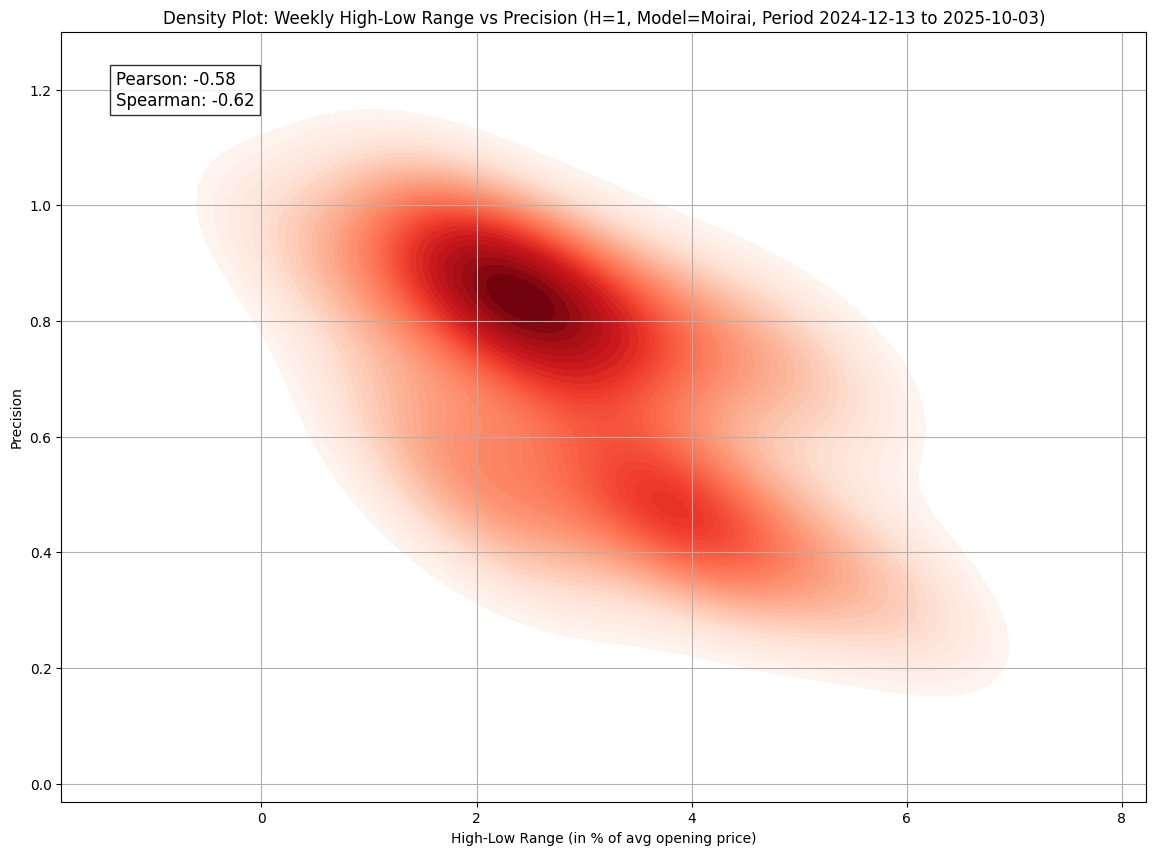

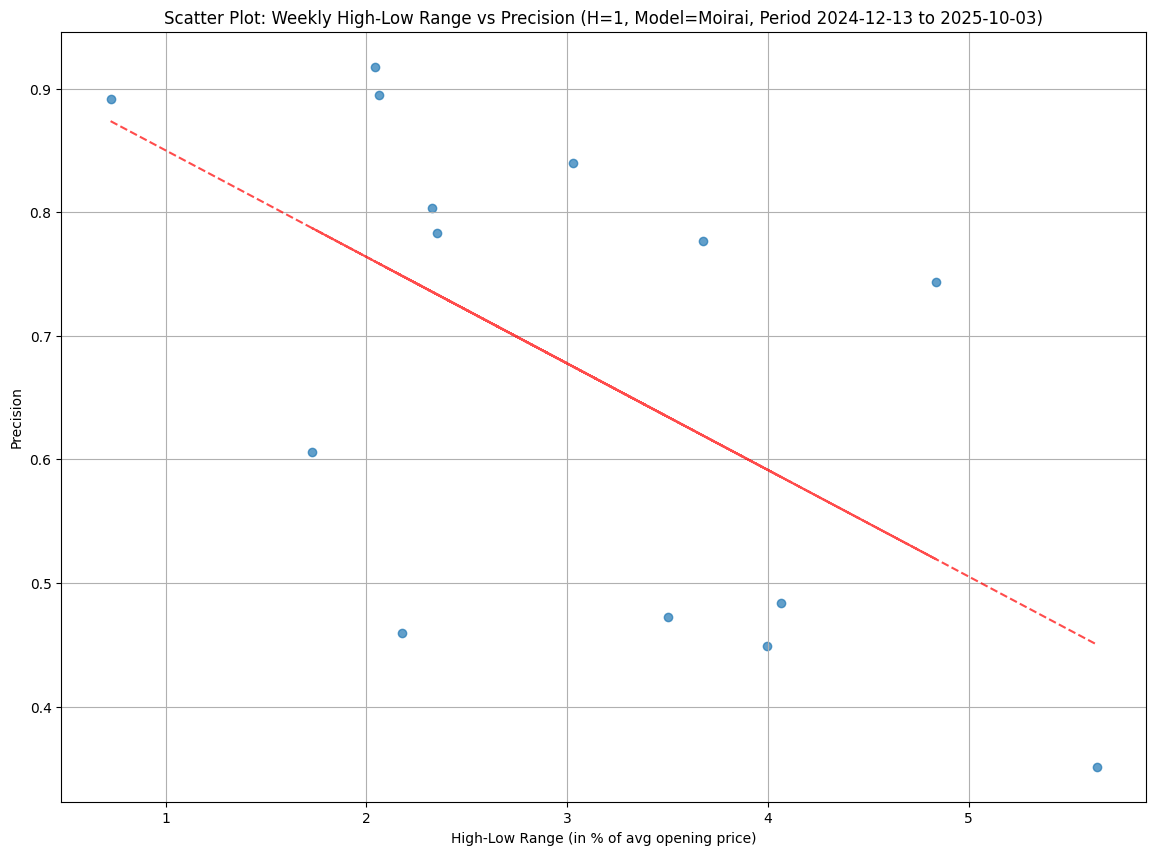

In [12]:
import pandas as pd
import ast
from math import prod
from datetime import datetime
import numpy as np

# We fix the horizon to 1 because otherwise it's too complicated to handle multiple horizons at the same time

# 1. Load the CSV (same file for all horizons)
df_moirai = pd.read_csv("analysis/future_data/test/es_future_final_moirai_2024_2025.csv")

# 2. Drop the first context_length rows because they have missing values for Result (NaN)
#    Keep the last 3 rows as a reference for the last 3 predicted values
df_moirai = df_moirai.drop(df_moirai.index[:383])

# 3. Shared configuration for all horizons
prediction_length = 3
horizon_index = 0
horizon = horizon_index + 1
last_index = df_moirai.index[-1]
last_index_for_es = last_index - prediction_length

# 4. Get the relevant values for a week
current_week_year = None
opening_price = 0
max_high = float('-inf')  # Initialize to negative infinity
min_low = float('inf')    # Initialize to positive infinity

# 5. Create a dictionary to store the values for each week
#    The keys will be the week-year combination and the values will be dictionaries containing
#    the precision values and the opening price, max high and min low
#    The dictionary will look like this:
#    {
#        "2023-W13": {
#            "precision_values": [(current_price, predicted_price, future_price)],
#            "opening_prices": [opening_price1, opening_price2, ...],
#            "max_high": max_high,
#            "min_low": min_low,
#            "high_low_range": high_low_range,
#            "precision": precision
#        },
#        ...
#    }
week_dict = {}

# 6. Iterate through DataFrame rows
for index_in_df, row in df_moirai.iterrows():
    current_price = float(row["Close"])
    if index_in_df > last_index_for_es:
        print(f"We will not use the last 3 values because we don't have the real values for all horizons (H={horizon}).")
        break

    predictions_list = ast.literal_eval(row["Result"])
    future_prices = df_moirai.loc[index_in_df:].iloc[1:prediction_length+1]["Close"].tolist()
    
    predicted_price = predictions_list[horizon_index]
    future_price = future_prices[horizon_index]

    # Get the date and determine week number and year
    date = datetime.fromisoformat(row["Datetime"]).date()
    year = date.year
    week = date.isocalendar()[1]  # Get ISO week number
    week_year_key = f"{year}-W{week:02d}"  # Format: "YYYY-WNN"
    
    current_high = float(row["High"])
    current_low = float(row["Low"])
    current_open = float(row["Open"])

    # if date == datetime.fromisoformat("2023-03-28").date():
    if date == datetime.fromisoformat("2024-12-12").date() or date == datetime.fromisoformat("2025-03-10").date():
        # This date as only one value so we can't do proper analysis
        continue

    if week_year_key == current_week_year:
        week_dict[week_year_key]["precision_values"].append((current_price, predicted_price, future_price))
        week_dict[week_year_key]["opening_prices"].append(current_open)
        # Update max high and min low
        week_dict[week_year_key]["max_high"] = max(week_dict[week_year_key]["max_high"], current_high)
        week_dict[week_year_key]["min_low"] = min(week_dict[week_year_key]["min_low"], current_low)
    else:
        current_week_year = week_year_key
        week_dict[week_year_key] = {}
        week_dict[week_year_key]["precision_values"] = [(current_price, predicted_price, future_price)]
        week_dict[week_year_key]["opening_prices"] = [current_open]
        week_dict[week_year_key]["max_high"] = current_high
        week_dict[week_year_key]["min_low"] = current_low

# 7. Compute the high-low range and precision for each week
for week_year_key, data in week_dict.items():
    # Calculate average opening price for the week
    opening_prices = data["opening_prices"]
    avg_opening_price = sum(opening_prices) / len(opening_prices)
    week_dict[week_year_key]["avg_opening_price"] = avg_opening_price
    
    # High-Low range in percentage of average opening price
    max_high = data["max_high"]
    min_low = data["min_low"]
    high_low_range = ((max_high - min_low) / avg_opening_price) * 100
    week_dict[week_year_key]["high_low_range"] = high_low_range
    
    # Precision
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    precision_values = data["precision_values"]
    for (current_price, predicted_price, future_price) in precision_values:
        sign_real_difference = np.sign(future_price - current_price)
        sign_prediction_difference = np.sign(predicted_price - current_price)
    
        if sign_prediction_difference == 1 and sign_real_difference == 1:
            TP += 1
        elif sign_prediction_difference == -1 and sign_real_difference == -1:
            TN += 1
        elif sign_prediction_difference == 1 and sign_real_difference == -1:
            FP += 1
        elif sign_prediction_difference == -1 and sign_real_difference == 1:
            FN += 1
    # Calculate precision
    if TP + FP == 0:
        precision = 0
    else:
        precision = TP / (TP + FP)
    # store this in the dictionary
    week_dict[week_year_key]["precision"] = precision
    # Store the number of data points for reference
    week_dict[week_year_key]["data_points"] = len(precision_values)

# 8. Plot the high-low range (x-axis) and precision (y-axis) using KDE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image

# Filter out weeks with too few data points (optional)
min_data_points = 5  # Minimum number of data points required for a week to be included
filtered_week_dict = {k: v for k, v in week_dict.items() if v["data_points"] >= min_data_points}

high_low_ranges = []
precisions = []
week_labels = []
for week_year_key, data in filtered_week_dict.items():
    high_low_ranges.append(data["high_low_range"])
    precisions.append(data["precision"])
    week_labels.append(week_year_key)

print("Number of weeks analyzed:", len(filtered_week_dict))
print("Max precision:", max(precisions))

# Créer un DataFrame à partir des listes
df = pd.DataFrame({
    'week': week_labels,
    'high_low_range': high_low_ranges,
    'precision': precisions
})

# Calculer les corrélations
pearson_corr = df[['high_low_range', 'precision']].corr(method='pearson')
spearman_corr = df[['high_low_range', 'precision']].corr(method='spearman')
print("Pearson Correlation:\n", pearson_corr)
print("Spearman Correlation:\n", spearman_corr)

# Créer un graphique KDE
plt.figure(figsize=(14, 10))
sns.kdeplot(data=df, x='high_low_range', y='precision', fill=True, cmap="Reds", levels=50)

# Ajouter les coefficients de corrélation comme texte
plt.text(0.05, 0.95, 
         f"Pearson: {pearson_corr.iloc[0, 1]:.2f}\nSpearman: {spearman_corr.iloc[0, 1]:.2f}", 
         fontsize=12, 
         transform=plt.gca().transAxes, 
         verticalalignment='top', 
         bbox=dict(facecolor='white', alpha=0.8))

# Titre et labels
plt.title("Density Plot: Weekly High-Low Range vs Precision (H=1, Model=Moirai, Period 2024-12-13 to 2025-10-03)")
plt.xlabel('High-Low Range (in % of avg opening price)')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

# Optional: Create a scatter plot to see the individual weeks
plt.figure(figsize=(14, 10))
scatter = plt.scatter(high_low_ranges, precisions, alpha=0.7)

# Add a trend line
z = np.polyfit(high_low_ranges, precisions, 1)
p = np.poly1d(z)
plt.plot(high_low_ranges, p(high_low_ranges), "r--", alpha=0.7)

plt.title("Scatter Plot: Weekly High-Low Range vs Precision (H=1, Model=Moirai, Period 2024-12-13 to 2025-10-03)")
plt.xlabel('High-Low Range (in % of avg opening price)')
plt.ylabel('Precision')
plt.grid(True)
plt.show()